# Feature Engineering — 10.03.2026

This notebook engineers and analyses candidate features for **short-term heat-demand forecasting** on the TalTech campus, using the cleaned pipeline outputs produced by `01_thesis_data_pipeline_09032026.ipynb`.

It now treats `01` as the source of truth for:
- the canonical hourly forecast target `heat_target_mwh`,
- cleaned subsystem `deltaT` / low-`deltaT` signals,
- and companion building metadata tables.

The notebook produces two explicit, per-building modelling datasets:
- `setA`: temporal weather, demand-memory, calendar, and system-dynamic features, including a raw observed heat channel `feat_heat_obs` for sequence models,
- `setB`: `setA` plus static building descriptors, structural EHR proxies, train-window summary features, and explicit missingness flags for imputed static metadata.

To keep `setB` usable across the full campus portfolio, static numeric features with partial coverage are median-imputed at the building level and paired with matching missingness indicators.


In [1]:
# Cell 0 — Imports, paths, and configuration

from pathlib import Path
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Matplotlib defaults for notebook plots
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 5)

# Project paths (relative to thesis-project root)
PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DIR = DATA_DIR / "clean"
EHR_DIR = DATA_DIR / "ehr-building-data"
FEATURE_DIR = DATA_DIR / "features"
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

WEATHER_CLEAN_FILE = CLEAN_DIR / "weather_hourly_clean.csv"
STATIC_FEATURES_FILE = CLEAN_DIR / "building_static_features.csv"
HEAT_TARGET_CATALOG_FILE = CLEAN_DIR / "heat_target_catalog.csv"
CAMPUS_MODEL_FEATURES_FILE = CLEAN_DIR / "campus_building_features_for_models.csv"
EHR_SUMMARY_FILE = EHR_DIR / "ehr_building_summary.csv"

# Buildings to include for broader campus / portfolio-style analysis.
CAMPUS_BUILDINGS = [
    "GEO", "ICO", "LIB", "SOC", "STU",
    "U01", "U01U02", "U02", "U02B",
    "U03", "U03B", "U04", "U04B",
    "U05", "U05B", "U06", "U06A",
]
PRIMARY_BUILDINGS = ["U06", "U05"]

# Global experiment configuration (aligned with baselines notebook)
TRAIN_END = "2023-12-31"  # train 2022-2023, test 2024
HEATING_THRESHOLD_C = 15.0
DELTA_T_LOW_THRESHOLD_C = 15.0
MIN_HEAT_LOAD_FOR_DELTAT_MWH = 0.001
NIGHT_HOURS = tuple(range(0, 6))
DAY_HOURS = tuple(range(8, 19))

# Wind chill (WCTSI) validity bounds
WINDCHILL_MAX_TEMP_C = 10.0
WINDCHILL_MIN_WIND_KPH = 4.8

# Full hourly grid used for index hygiene (same as baselines)
FULL_GRID = pd.date_range("2022-01-01", "2024-12-31 23:00", freq="h")

print(f"Project root        : {PROJECT_ROOT}")
print(f"Clean data          : {CLEAN_DIR}")
print(f"Static features     : {STATIC_FEATURES_FILE.name}")
print(f"Heat target catalog : {HEAT_TARGET_CATALOG_FILE.name}")
print(f"Features dir        : {FEATURE_DIR}")
print(f"Buildings           : {len(CAMPUS_BUILDINGS)}  (primary: {PRIMARY_BUILDINGS})")
print(f"Train window        : up to {TRAIN_END}  |  Test window: 2024")


Project root        : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project
Clean data          : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/clean
Static features     : building_static_features.csv
Heat target catalog : heat_target_catalog.csv
Features dir        : /Users/mihkeluutar/Documents/TalTech/Thesis/thesis-project/data/features
Buildings           : 17  (primary: ['U06', 'U05'])
Train window        : up to 2023-12-31  |  Test window: 2024


In [2]:
# Cell 1 — Load clean data and per-building coverage

import re

HOURLY_SYSTEM_COLS = [
    "bldg_space_heat_mwh",
    "bldg_space_heat_deltaT_c",
    "bldg_space_heat_low_deltaT_flag",
    "bldg_vent_heat_mwh",
    "bldg_vent_heat_deltaT_c",
    "bldg_vent_heat_low_deltaT_flag",
    "bldg_dhw_mwh",
    "bldg_dhw_deltaT_c",
    "bldg_dhw_low_deltaT_flag",
    "bldg_weather_driven_heat_mwh",
]

EHR_CODE_MAP = {
    "U01": "U01",
    "U02 (+U02B)": "U02",
    "U03 (+U03B)": "U03",
    "U04": "U04",
    "U04B": "U04B",
    "U05": "U05",
    "U05B": "U05B",
    "U06 (+U06A)": "U06",
    "GEO": "GEO",
    "STU": "STU",
    "LIB": "LIB",
    "SOC": "SOC",
    "ICO": "ICO",
}
EHR_ANNEX_MAP = {"U02B": "U02", "U03B": "U03", "U06A": "U06"}


def apply_index_hygiene(df: pd.DataFrame, label: str) -> tuple[pd.DataFrame, dict]:
    """Sort, deduplicate, strip timezone, and reindex to FULL_GRID."""
    issues = {"duplicates": 0, "gaps_filled": 0}

    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)

    df = df.sort_index()
    n_dup = int(df.index.duplicated().sum())
    if n_dup:
        df = df[~df.index.duplicated(keep="last")]
        issues["duplicates"] = n_dup

    assert df.index.is_monotonic_increasing, f"{label}: index not monotonic after sort"

    n_before = len(df)
    df = df.reindex(FULL_GRID)
    issues["gaps_filled"] = int(len(df) - n_before)
    return df, issues


def _load_hourly_clean(fpath: Path) -> pd.DataFrame:
    raw = pd.read_csv(fpath)
    if "datetime" in raw.columns:
        dt_col = "datetime"
    elif "Unnamed: 0" in raw.columns:
        dt_col = "Unnamed: 0"
    else:
        raise ValueError("missing datetime column")
    raw[dt_col] = pd.to_datetime(raw[dt_col])
    return raw.rename(columns={dt_col: "datetime"}).set_index("datetime")


def _safe_numeric(obj, col: str | None = None) -> pd.Series:
    series = obj[col] if col is not None else obj
    return pd.to_numeric(series, errors="coerce")


# 1a. Load weather clean file from the canonical pipeline outputs
wx_raw = pd.read_csv(WEATHER_CLEAN_FILE, parse_dates=["datetime"]).set_index("datetime")
wx_df, wx_issues = apply_index_hygiene(wx_raw, "weather")
print(f"Weather loaded: {len(wx_df):,} rows | "
      f"duplicates fixed={wx_issues['duplicates']} | gaps filled={wx_issues['gaps_filled']}")

# 1b. Load static companion tables from 01
static_companion_df = pd.read_csv(STATIC_FEATURES_FILE)
static_companion_df = static_companion_df.drop_duplicates(subset=["building_abv"]).copy()
static_companion_df["building_abv"] = static_companion_df["building_abv"].astype(str)

heat_target_catalog_df = pd.read_csv(HEAT_TARGET_CATALOG_FILE)
heat_target_catalog_df = heat_target_catalog_df.drop_duplicates(subset=["building_abv"]).copy()
heat_target_catalog_df["building_abv"] = heat_target_catalog_df["building_abv"].astype(str)

target_meta_lookup = (
    heat_target_catalog_df
    .set_index("building_abv")[["heat_target_kind", "heat_target_source"]]
    .to_dict(orient="index")
)

print("Canonical target kinds:")
print(heat_target_catalog_df["heat_target_kind"].value_counts(dropna=False).to_string())

# 1c. Load raw EHR summary for structural proxy features that are not yet in the
# 01 static companion table (e.g. compactness, orientation, max floors).
ehr_summary = pd.read_csv(EHR_SUMMARY_FILE)
ehr_lookup = {}
for _, row in ehr_summary.iterrows():
    bldg = EHR_CODE_MAP.get(str(row.get("campus_code", "")))
    if not bldg:
        continue
    ehr_lookup[bldg] = row
for annex, primary in EHR_ANNEX_MAP.items():
    if primary in ehr_lookup and annex not in ehr_lookup:
        ehr_lookup[annex] = ehr_lookup[primary]

print("Structural EHR entries available for:", sorted(ehr_lookup.keys()))

# 1d. Load building clean CSVs and compute per-building target coverage
building_dfs: dict[str, pd.DataFrame] = {}
coverage_rows = []

area_lookup = (
    static_companion_df.assign(
        heated_area_m2=lambda d: pd.to_numeric(d["heated_area_m2"], errors="coerce")
    )
    .set_index("building_abv")["heated_area_m2"]
    .to_dict()
)

for bldg in CAMPUS_BUILDINGS:
    fpath = CLEAN_DIR / f"{bldg}_hourly_clean.csv"
    if not fpath.exists():
        coverage_rows.append({
            "building": bldg,
            "status": "FILE_MISSING",
            "target_kind": pd.NA,
            "target_source": pd.NA,
            "first_obs": pd.NaT,
            "last_obs": pd.NaT,
            "train_rows": 0,
            "train_nonnull": 0,
            "test_rows": 0,
            "test_nonnull": 0,
        })
        continue

    raw = _load_hourly_clean(fpath)
    raw, issues = apply_index_hygiene(raw, bldg)

    if "heat_target_mwh" not in raw.columns:
        coverage_rows.append({
            "building": bldg,
            "status": "NO_HEAT_TARGET",
            "target_kind": pd.NA,
            "target_source": pd.NA,
            "first_obs": pd.NaT,
            "last_obs": pd.NaT,
            "train_rows": 0,
            "train_nonnull": 0,
            "test_rows": 0,
            "test_nonnull": 0,
        })
        continue

    target_meta = target_meta_lookup.get(bldg, {})
    target_kind = target_meta.get("heat_target_kind", pd.NA)
    target_source = target_meta.get("heat_target_source", pd.NA)

    mdf = pd.DataFrame(index=raw.index)
    mdf["heat_mwh"] = _safe_numeric(raw, "heat_target_mwh")
    mdf["heat_kwh"] = mdf["heat_mwh"] * 1000.0

    for col in HOURLY_SYSTEM_COLS:
        if col in raw.columns:
            if col.endswith("_flag"):
                mdf[col] = raw[col].fillna(False).astype(bool)
            else:
                mdf[col] = _safe_numeric(raw, col)
        else:
            mdf[col] = False if col.endswith("_flag") else np.nan

    # Join canonical weather subset (extended later if humidity is available).
    wx_cols = [
        "wx_outdoor_temp_c",
        "wx_wind_ms",
        "wx_solar_irradiance_Wm2",
        "wx_sunshine_min",
    ]
    mdf = mdf.join(wx_df[wx_cols], how="left")

    area_val = pd.to_numeric(area_lookup.get(bldg, np.nan), errors="coerce")
    mdf["heat_kwh_m2"] = mdf["heat_kwh"] / area_val if pd.notna(area_val) and area_val > 0 else np.nan
    mdf["heat_target_kind"] = target_kind
    mdf["heat_target_source"] = target_source

    building_dfs[bldg] = mdf

    nonnull_mask = mdf["heat_kwh"].notna()
    if nonnull_mask.any():
        first_obs = mdf.index[nonnull_mask.argmax()]
        last_obs = mdf.index[::-1][nonnull_mask[::-1].argmax()]
    else:
        first_obs = pd.NaT
        last_obs = pd.NaT

    train_mask = mdf.index <= TRAIN_END
    test_mask = mdf.index > TRAIN_END

    coverage_rows.append({
        "building": bldg,
        "status": "OK",
        "target_kind": target_kind,
        "target_source": target_source,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "train_rows": int(train_mask.sum()),
        "train_nonnull": int((train_mask & nonnull_mask).sum()),
        "test_rows": int(test_mask.sum()),
        "test_nonnull": int((test_mask & nonnull_mask).sum()),
        "duplicates_fixed": issues["duplicates"],
        "gaps_filled": issues["gaps_filled"],
    })

coverage_df = pd.DataFrame(coverage_rows).sort_values("building").reset_index(drop=True)

print("\nPer-building target coverage (rows, non-null counts):")
display_cols = [
    "building", "status", "target_kind", "first_obs", "last_obs",
    "train_rows", "train_nonnull", "test_rows", "test_nonnull",
]
print(coverage_df[display_cols].to_string(index=False))


Weather loaded: 26,304 rows | duplicates fixed=0 | gaps filled=0
Canonical target kinds:
heat_target_kind
weather_driven    15
total_heat         2
Structural EHR entries available for: ['GEO', 'ICO', 'LIB', 'SOC', 'STU', 'U01', 'U02', 'U02B', 'U03', 'U03B', 'U04', 'U04B', 'U05', 'U05B', 'U06', 'U06A']

Per-building target coverage (rows, non-null counts):
building status    target_kind           first_obs            last_obs  train_rows  train_nonnull  test_rows  test_nonnull
     GEO     OK weather_driven 2022-05-23 12:00:00 2024-12-31 23:00:00       17497          14077       8807          8807
     ICO     OK weather_driven 2022-05-20 13:00:00 2024-12-31 23:00:00       17497          14148       8807          8807
     LIB     OK weather_driven 2022-05-20 14:00:00 2024-12-31 23:00:00       17497          14147       8807          8807
     SOC     OK weather_driven 2022-05-20 14:00:00 2024-12-31 23:00:00       17497          14147       8807          8807
     STU     OK     total_

In [3]:
# Cell 2 — Extract relative humidity from keskkonnaportaal raw data

from pathlib import Path as _Path

KKP_RAW_FILE = DATA_DIR / "keskkonnaportaal" / "tallinn-harku_f_kliima_tund.csv"

if KKP_RAW_FILE.exists():
    kkp_raw = pd.read_csv(
        KKP_RAW_FILE,
        sep=";",
        header=0,
        quotechar='"',
        encoding="utf-8",
    )

    kkp_raw.columns = [
        "station_code",
        "station_name",
        "year",
        "month",
        "day",
        "hour",
        "value",
        "element_code",
        "element_name_eng",
        "element_unit_eng",
        "published_ts",
    ]

    kkp_raw["value"] = (
        kkp_raw["value"].astype(str).str.replace(",", ".", regex=False).astype(float)
    )

    dt = pd.to_datetime(
        dict(
            year=kkp_raw["year"],
            month=kkp_raw["month"],
            day=kkp_raw["day"],
            hour=kkp_raw["hour"],
        ),
        utc=False,
    )
    kkp_raw["datetime"] = dt

    kkp_wide = (
        kkp_raw
        .pivot_table(
            index="datetime",
            columns="element_code",
            values="value",
            aggfunc="mean",
        )
        .sort_index()
    )

    if "RH" in kkp_wide.columns:
        rh_series = kkp_wide["RH"].reindex(FULL_GRID)
        wx_df["wx_relative_humidity_pct"] = rh_series
        for bldg, mdf in building_dfs.items():
            mdf["wx_relative_humidity_pct"] = wx_df["wx_relative_humidity_pct"]
            building_dfs[bldg] = mdf
        print("Added wx_relative_humidity_pct from keskkonnaportaal (RH element).")
    else:
        print("RH element not found in keskkonnaportaal file; skipping humidity feature.")
else:
    print("Keskkonnaportaal raw file not found; skipping humidity extraction.")


Added wx_relative_humidity_pct from keskkonnaportaal (RH element).


In [4]:
# Cell 3 — Engineer dynamic candidate features (weather, demand memory, system, calendar)

from typing import Dict

SYSTEM_DYNAMIC_SPECS = {
    "space": {
        "load_col": "bldg_space_heat_mwh",
        "delta_col": "bldg_space_heat_deltaT_c",
        "low_col": "bldg_space_heat_low_deltaT_flag",
    },
    "vent": {
        "load_col": "bldg_vent_heat_mwh",
        "delta_col": "bldg_vent_heat_deltaT_c",
        "low_col": "bldg_vent_heat_low_deltaT_flag",
    },
    "dhw": {
        "load_col": "bldg_dhw_mwh",
        "delta_col": "bldg_dhw_deltaT_c",
        "low_col": "bldg_dhw_low_deltaT_flag",
    },
}

FEATURE_GROUP_DYNAMIC: Dict[str, list[str]] = {}

for bldg, df in building_dfs.items():
    mdf = df.copy()

    temp = _safe_numeric(mdf, "wx_outdoor_temp_c")
    wind_ms = _safe_numeric(mdf, "wx_wind_ms")
    wind_kph = wind_ms * 3.6
    v16 = np.power(np.clip(wind_kph, 0, None), 0.16)

    # Group A: weather-derived features
    mdf["feat_outdoor_temp_c"] = temp

    wctsi = 13.12 + 0.6215 * temp - 11.37 * v16 + 0.3965 * temp * v16
    valid_mask = (temp <= WINDCHILL_MAX_TEMP_C) & (wind_kph >= WINDCHILL_MIN_WIND_KPH)
    mdf["feat_windchill_c"] = np.where(valid_mask, wctsi, temp)
    mdf["feat_hdh_15c"] = np.maximum(0.0, 15.0 - temp)
    mdf["feat_is_heating_weather"] = (temp < HEATING_THRESHOLD_C).astype(float)

    mdf["feat_temp_roll6h"] = temp.rolling(6, min_periods=1).mean()
    mdf["feat_temp_roll12h"] = temp.rolling(12, min_periods=1).mean()
    mdf["feat_temp_roll24h"] = temp.rolling(24, min_periods=1).mean()
    mdf["feat_temp_diff1h"] = temp.diff(1)
    mdf["feat_temp_diff3h"] = temp.diff(3)

    if "wx_relative_humidity_pct" in mdf.columns:
        mdf["feat_rh_pct"] = _safe_numeric(mdf, "wx_relative_humidity_pct")
    if "wx_solar_irradiance_Wm2" in mdf.columns:
        mdf["feat_solar_irradiance_wm2"] = _safe_numeric(mdf, "wx_solar_irradiance_Wm2")
    if "wx_sunshine_min" in mdf.columns:
        mdf["feat_sunshine_min"] = _safe_numeric(mdf, "wx_sunshine_min")
    mdf["feat_wind_ms"] = wind_ms

    # Group B: demand-memory features
    # Keep the raw observed heat channel so sequence models can directly see the latest load state.
    mdf["feat_heat_obs"] = mdf["heat_kwh"]
    mdf["feat_heat_lag1"] = mdf["heat_kwh"].shift(1)
    mdf["feat_heat_lag2"] = mdf["heat_kwh"].shift(2)
    mdf["feat_heat_lag3"] = mdf["heat_kwh"].shift(3)
    mdf["feat_heat_lag24"] = mdf["heat_kwh"].shift(24)
    mdf["feat_heat_lag168"] = mdf["heat_kwh"].shift(168)
    mdf["feat_heat_roll6h"] = mdf["heat_kwh"].rolling(6, min_periods=1).mean()
    mdf["feat_heat_roll24h"] = mdf["heat_kwh"].rolling(24, min_periods=1).mean()

    # Group C: system-dynamic features from canonical subsystem deltaT and low-deltaT signals.
    for token, spec in SYSTEM_DYNAMIC_SPECS.items():
        load_series = _safe_numeric(mdf, spec["load_col"]).fillna(0.0)
        delta_series = _safe_numeric(mdf, spec["delta_col"])
        low_series = mdf[spec["low_col"]].fillna(False).astype(float)

        active = (load_series > MIN_HEAT_LOAD_FOR_DELTAT_MWH).astype(float)
        delta_filled = delta_series.where(active > 0, 0.0).fillna(0.0)
        low_series = np.where(active > 0, low_series, 0.0)
        low_series = pd.Series(low_series, index=mdf.index, dtype=float)

        mdf[f"feat_{token}_heat_active"] = active
        mdf[f"feat_{token}_deltaT_c"] = delta_filled
        mdf[f"feat_{token}_deltaT_lag1"] = delta_filled.shift(1)
        mdf[f"feat_{token}_deltaT_roll6h"] = delta_filled.rolling(6, min_periods=1).mean()
        mdf[f"feat_{token}_deltaT_roll24h"] = delta_filled.rolling(24, min_periods=1).mean()
        mdf[f"feat_{token}_low_deltaT_flag"] = low_series
        mdf[f"feat_{token}_low_deltaT_roll24h"] = low_series.rolling(24, min_periods=1).mean()

    # Group D: calendar / schedule features
    idx = mdf.index
    hour = idx.hour
    dow = idx.dayofweek
    month = idx.month

    mdf["feat_hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    mdf["feat_hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    mdf["feat_dow_sin"] = np.sin(2 * np.pi * dow / 7.0)
    mdf["feat_dow_cos"] = np.cos(2 * np.pi * dow / 7.0)
    mdf["feat_month_sin"] = np.sin(2 * np.pi * month / 12.0)
    mdf["feat_month_cos"] = np.cos(2 * np.pi * month / 12.0)
    mdf["feat_is_weekend"] = (dow >= 5).astype(float)
    mdf["feat_is_night"] = np.isin(hour, NIGHT_HOURS).astype(float)
    mdf["feat_is_daytime"] = np.isin(hour, DAY_HOURS).astype(float)

    building_dfs[bldg] = mdf
    FEATURE_GROUP_DYNAMIC[bldg] = sorted(c for c in mdf.columns if c.startswith("feat_"))

all_dynamic_features = sorted({f for cols in FEATURE_GROUP_DYNAMIC.values() for f in cols})
rows = []
for bldg, mdf in building_dfs.items():
    for feat in all_dynamic_features:
        if feat in mdf.columns:
            rows.append({
                "building": bldg,
                "feature": feat,
                "nonnull": int(mdf[feat].notna().sum()),
            })

feature_coverage_df = pd.DataFrame(rows)
print("\nDynamic feature coverage (non-null counts, sample):")
print(feature_coverage_df.head(30).to_string(index=False))



Dynamic feature coverage (non-null counts, sample):
building                     feature  nonnull
     GEO           feat_dhw_deltaT_c    26304
     GEO        feat_dhw_deltaT_lag1    26303
     GEO     feat_dhw_deltaT_roll24h    26304
     GEO      feat_dhw_deltaT_roll6h    26304
     GEO        feat_dhw_heat_active    26304
     GEO    feat_dhw_low_deltaT_flag    26304
     GEO feat_dhw_low_deltaT_roll24h    26304
     GEO                feat_dow_cos    26304
     GEO                feat_dow_sin    26304
     GEO                feat_hdh_15c    26304
     GEO              feat_heat_lag1    22883
     GEO            feat_heat_lag168    22716
     GEO              feat_heat_lag2    22882
     GEO             feat_heat_lag24    22860
     GEO              feat_heat_lag3    22881
     GEO               feat_heat_obs    22884
     GEO           feat_heat_roll24h    22884
     GEO            feat_heat_roll6h    22884
     GEO               feat_hour_cos    26304
     GEO               feat

In [5]:
# Cell 3b — Engineer static building descriptors, structural EHR proxies, and train-window summaries

def slugify(text: str) -> str:
    text = unicodedata.normalize("NFKD", str(text)).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"[^a-zA-Z0-9]+", "_", text.strip().lower())
    text = re.sub(r"_+", "_", text).strip("_")
    return text or "unknown"


def encode_structural_mass(material: str) -> float:
    if not isinstance(material, str):
        return np.nan
    mat = material.lower()
    if "puit" in mat or "wood" in mat:
        return 0.0
    if "metall" in mat or "steel" in mat:
        return 0.5
    if "tellis" in mat or "brick" in mat:
        return 1.0
    if "monoliit" in mat or "raudbetoon" in mat or "betoon" in mat:
        return 2.0
    return np.nan


def encode_wall_type(wall: str) -> float:
    if not isinstance(wall, str):
        return np.nan
    w = wall.lower()
    if "termoprofiil" in w or "light" in w or "panel" in w:
        return 0.0
    if "tellis" in w or "brick" in w:
        return 1.0
    if "raudbetoon" in w or "paneel" in w:
        return 2.0
    return np.nan


def has_heat_recovery(ventilation_type: str) -> float:
    if not isinstance(ventilation_type, str):
        return 0.0
    v = ventilation_type.lower()
    return float("soojustagastusega" in v or "heat recovery" in v)


def has_cooling(cooling_system: str) -> float:
    if not isinstance(cooling_system, str):
        return 0.0
    v = cooling_system.strip().lower()
    return float(v not in {"", "nan", "puudub"})


def _safe_autocorr(series: pd.Series, lag: int) -> float:
    clean = series.dropna()
    if len(clean) <= lag + 1:
        return np.nan
    return float(clean.autocorr(lag))


def _missing_flag_name(feature_name: str) -> str:
    if feature_name.startswith("stat_train_"):
        return "stat_train_missing_" + feature_name[len("stat_train_"):]
    if feature_name.startswith("stat_"):
        return "stat_missing_" + feature_name[len("stat_"):]
    if feature_name.startswith("ehr_"):
        return "ehr_missing_" + feature_name[len("ehr_"):]
    return f"missing_{feature_name}"


def _summarise_deltaT_train(df: pd.DataFrame, token: str, row: dict) -> None:
    delta_col = f"bldg_{token}_deltaT_c"
    load_col = f"bldg_{token}_mwh"
    if delta_col not in df.columns or load_col not in df.columns:
        return
    heating = _safe_numeric(df, "wx_outdoor_temp_c") < HEATING_THRESHOLD_C
    active = heating & (_safe_numeric(df, load_col) > MIN_HEAT_LOAD_FOR_DELTAT_MWH)
    vals = _safe_numeric(df.loc[active], delta_col).dropna()
    if vals.empty:
        return
    suffix = token.replace("_heat", "")
    row[f"stat_train_deltaT_{suffix}_median"] = float(vals.median())
    row[f"stat_train_deltaT_{suffix}_p10"] = float(vals.quantile(0.10))
    row[f"stat_train_deltaT_{suffix}_p90"] = float(vals.quantile(0.90))
    row[f"stat_train_share_low_deltaT_{suffix}"] = float((vals < DELTA_T_LOW_THRESHOLD_C).mean())


# A. Static building descriptors exported by 01
static_base = static_companion_df.set_index("building_abv").copy()
for col in [
    "n_points",
    "n_vent_points",
    "n_heat_points",
    "n_dhw_points",
    "has_multiple_hoone_labels",
    "heated_area_m2",
    "usage_non_res_share_of_heated",
    "building_age_years",
    "heated_area_missing",
    "has_energy_class",
]:
    static_base[col] = pd.to_numeric(static_base[col], errors="coerce")

static_descriptor_df = pd.DataFrame(index=static_base.index)
static_descriptor_df["stat_n_points"] = static_base["n_points"]
static_descriptor_df["stat_n_vent_points"] = static_base["n_vent_points"]
static_descriptor_df["stat_n_heat_points"] = static_base["n_heat_points"]
static_descriptor_df["stat_n_dhw_points"] = static_base["n_dhw_points"]
static_descriptor_df["stat_has_multiple_hoone_labels"] = static_base["has_multiple_hoone_labels"]
static_descriptor_df["stat_heated_area_m2"] = static_base["heated_area_m2"]
static_descriptor_df["stat_usage_non_res_share_of_heated"] = static_base["usage_non_res_share_of_heated"]
static_descriptor_df["stat_building_age_years"] = static_base["building_age_years"]
static_descriptor_df["stat_heated_area_missing"] = static_base["heated_area_missing"]
static_descriptor_df["stat_has_energy_class"] = static_base["has_energy_class"]
static_descriptor_df["stat_ventilation_has_heat_recovery"] = static_base["ventilation_type"].apply(has_heat_recovery)
static_descriptor_df["stat_has_cooling_system"] = static_base["cooling_system"].apply(has_cooling)

for source_col, prefix in [
    ("vent_class", "stat_vent_class"),
    ("energy_class", "stat_energy_class"),
    ("building_type", "stat_building_type"),
    ("ventilation_type", "stat_ventilation_type"),
    ("cooling_system", "stat_cooling_system"),
]:
    categories = sorted({
        str(v).strip() for v in static_base[source_col].dropna().tolist()
        if str(v).strip() and str(v).strip().lower() != "nan"
    })
    for category in categories:
        col_name = f"{prefix}_{slugify(category)}"
        static_descriptor_df[col_name] = (
            static_base[source_col].fillna("").astype(str).str.strip() == category
        ).astype(float)

STATIC_DESCRIPTOR_FEATURES = static_descriptor_df.columns.tolist()

# B. Structural EHR proxies that complement the 01 static export
EHR_STRUCTURAL_FEATURES = [
    "ehr_volume_per_heated_area",
    "ehr_compactness_ratio",
    "ehr_max_floors",
    "ehr_height_per_floor_m",
    "ehr_plan_aspect_ratio",
    "ehr_orientation_sin2",
    "ehr_orientation_cos2",
    "ehr_has_heat_recovery",
    "ehr_structural_mass_code",
    "ehr_wall_type_code",
]

ehr_structural_rows = []
for bldg in CAMPUS_BUILDINGS:
    row = {"building": bldg, **{feat: np.nan for feat in EHR_STRUCTURAL_FEATURES}}
    ehr_row = ehr_lookup.get(bldg)
    if ehr_row is not None:
        row["ehr_volume_per_heated_area"] = ehr_row.get("volume_per_heated_area", np.nan)
        row["ehr_compactness_ratio"] = ehr_row.get("compactness_ratio", np.nan)
        row["ehr_max_floors"] = ehr_row.get("max_floors", np.nan)
        row["ehr_height_per_floor_m"] = ehr_row.get("height_per_floor_m", np.nan)
        row["ehr_plan_aspect_ratio"] = ehr_row.get("plan_aspect_ratio", np.nan)
        row["ehr_orientation_sin2"] = ehr_row.get("orientation_sin2", np.nan)
        row["ehr_orientation_cos2"] = ehr_row.get("orientation_cos2", np.nan)
        row["ehr_has_heat_recovery"] = has_heat_recovery(ehr_row.get("ventilation_type", np.nan))
        row["ehr_structural_mass_code"] = encode_structural_mass(ehr_row.get("structural_material", np.nan))
        row["ehr_wall_type_code"] = encode_wall_type(ehr_row.get("wall_type", np.nan))
    ehr_structural_rows.append(row)

ehr_structural_df = pd.DataFrame(ehr_structural_rows).set_index("building")

# C. Train-window summary features (computed from 2022-2023 only to avoid leakage)
train_summary_rows = []
for bldg, mdf in building_dfs.items():
    train_df = mdf.loc[mdf.index <= TRAIN_END].copy()
    area_val = pd.to_numeric(static_base.loc[bldg, "heated_area_m2"], errors="coerce") if bldg in static_base.index else np.nan
    heat = _safe_numeric(train_df, "heat_mwh")
    heating = heat.loc[_safe_numeric(train_df, "wx_outdoor_temp_c") < HEATING_THRESHOLD_C]

    daily = (
        heat.to_frame("heat_mwh")
        .resample("D")
        .sum(min_count=1)
    )
    daily["temp_mean_c"] = _safe_numeric(train_df, "wx_outdoor_temp_c").resample("D").mean()
    daily["heat_mwh_per_m2"] = daily["heat_mwh"] / area_val if pd.notna(area_val) and area_val > 0 else np.nan

    row = {
        "building": bldg,
        "stat_train_heat_demand_mean_daily_mwh": float(daily["heat_mwh"].mean()) if daily["heat_mwh"].notna().any() else np.nan,
        "stat_train_heat_demand_total_mwh": float(daily["heat_mwh"].sum()) if daily["heat_mwh"].notna().any() else np.nan,
        "stat_train_heat_demand_per_m2_mwh_per_day": np.nan,
        "stat_train_ac1": _safe_autocorr(heating, 1),
        "stat_train_ac24": _safe_autocorr(heating, 24),
        "stat_train_night_mean_heat_per_m2": np.nan,
        "stat_train_day_mean_heat_per_m2": np.nan,
        "stat_train_night_day_ratio": np.nan,
        "stat_train_slope_heat_per_m2_per_deg": np.nan,
        "stat_train_intercept_heat_per_m2": np.nan,
        "stat_train_daily_corr_heat_temp": np.nan,
        "stat_train_deltaT_space_median": np.nan,
        "stat_train_deltaT_space_p10": np.nan,
        "stat_train_deltaT_space_p90": np.nan,
        "stat_train_share_low_deltaT_space": np.nan,
        "stat_train_deltaT_vent_median": np.nan,
        "stat_train_deltaT_vent_p10": np.nan,
        "stat_train_deltaT_vent_p90": np.nan,
        "stat_train_share_low_deltaT_vent": np.nan,
        "stat_train_deltaT_dhw_median": np.nan,
        "stat_train_deltaT_dhw_p10": np.nan,
        "stat_train_deltaT_dhw_p90": np.nan,
        "stat_train_share_low_deltaT_dhw": np.nan,
    }

    row["stat_train_heat_demand_per_m2_mwh_per_day"] = (
        row["stat_train_heat_demand_mean_daily_mwh"] / area_val
        if pd.notna(area_val) and area_val > 0 and pd.notna(row["stat_train_heat_demand_mean_daily_mwh"])
        else np.nan
    )

    _summarise_deltaT_train(train_df, "space_heat", row)
    _summarise_deltaT_train(train_df, "vent_heat", row)
    _summarise_deltaT_train(train_df, "dhw", row)

    h_df = heating.to_frame("heat_mwh")
    h_df["hour"] = h_df.index.hour
    h_df["heat_mwh_per_m2"] = h_df["heat_mwh"] / area_val if pd.notna(area_val) and area_val > 0 else np.nan
    night = h_df[h_df["hour"].isin(NIGHT_HOURS)]
    day = h_df[h_df["hour"].isin(DAY_HOURS)]
    row["stat_train_night_mean_heat_per_m2"] = float(night["heat_mwh_per_m2"].mean()) if not night.empty else np.nan
    row["stat_train_day_mean_heat_per_m2"] = float(day["heat_mwh_per_m2"].mean()) if not day.empty else np.nan
    row["stat_train_night_day_ratio"] = (
        row["stat_train_night_mean_heat_per_m2"] / row["stat_train_day_mean_heat_per_m2"]
        if pd.notna(row["stat_train_day_mean_heat_per_m2"]) and row["stat_train_day_mean_heat_per_m2"] != 0
        else np.nan
    )

    slope_df = daily.dropna(subset=["heat_mwh_per_m2", "temp_mean_c"]).copy()
    if len(slope_df) >= 10:
        a, b0 = np.polyfit(slope_df["temp_mean_c"].values, slope_df["heat_mwh_per_m2"].values, 1)
        row["stat_train_slope_heat_per_m2_per_deg"] = float(a)
        row["stat_train_intercept_heat_per_m2"] = float(b0)
        row["stat_train_daily_corr_heat_temp"] = float(slope_df["heat_mwh_per_m2"].corr(slope_df["temp_mean_c"]))

    train_summary_rows.append(row)

train_summary_df = pd.DataFrame(train_summary_rows).set_index("building")
TRAIN_SUMMARY_FEATURES = train_summary_df.columns.tolist()

# D. Combine, add missingness flags, and broadcast static features to each building frame
static_feature_table = (
    static_descriptor_df
    .join(ehr_structural_df, how="outer")
    .join(train_summary_df, how="outer")
    .reindex(CAMPUS_BUILDINGS)
)

STATIC_IMPUTED_FEATURES = STATIC_DESCRIPTOR_FEATURES + EHR_STRUCTURAL_FEATURES + TRAIN_SUMMARY_FEATURES
STATIC_MISSINGNESS_FEATURES = []
imputation_rows = []

for feat in STATIC_IMPUTED_FEATURES:
    series = pd.to_numeric(static_feature_table[feat], errors="coerce")
    if series.isna().any():
        miss_col = _missing_flag_name(feat)
        fill_value = float(series.median()) if series.notna().any() else 0.0
        static_feature_table[miss_col] = series.isna().astype(float)
        static_feature_table[feat] = series.fillna(fill_value)
        STATIC_MISSINGNESS_FEATURES.append(miss_col)
        imputation_rows.append({
            "feature": feat,
            "missing_buildings": int(series.isna().sum()),
            "fill_value": fill_value,
            "missing_flag": miss_col,
        })
    else:
        static_feature_table[feat] = series

STATIC_ALL_FEATURES = STATIC_IMPUTED_FEATURES + STATIC_MISSINGNESS_FEATURES

print("Static feature preview (first rows, selected columns):")
preview_cols = STATIC_DESCRIPTOR_FEATURES[:8] + EHR_STRUCTURAL_FEATURES[:4] + TRAIN_SUMMARY_FEATURES[:6]
print(static_feature_table[preview_cols].head().to_string())

if imputation_rows:
    print()
    print("Static features imputed for portfolio completeness:")
    print(pd.DataFrame(imputation_rows).to_string(index=False))
else:
    print()
    print("No static feature imputations were required.")

for bldg, mdf in building_dfs.items():
    if bldg not in static_feature_table.index:
        continue
    for feat in STATIC_ALL_FEATURES:
        mdf[feat] = static_feature_table.loc[bldg, feat]
    building_dfs[bldg] = mdf


Static feature preview (first rows, selected columns):
              stat_n_points  stat_n_vent_points  stat_n_heat_points  stat_n_dhw_points  stat_has_multiple_hoone_labels  stat_heated_area_m2  stat_usage_non_res_share_of_heated  stat_building_age_years  ehr_volume_per_heated_area  ehr_compactness_ratio  ehr_max_floors  ehr_height_per_floor_m  stat_train_heat_demand_mean_daily_mwh  stat_train_heat_demand_total_mwh  stat_train_heat_demand_per_m2_mwh_per_day  stat_train_ac1  stat_train_ac24  stat_train_night_mean_heat_per_m2
building_abv                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_47862/113165793.py:293: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mdf[feat] = static_feature_table.loc[bldg, feat]
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_47862/113165793.py:293: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mdf[feat] = static_feature_table.loc[bldg, feat]
/var/folders/3x/zbbhfv350l7g455kz77dzgzh0000gn/T/ipykernel_47862/113165793.py:293: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fra


U06 — feature relevance (heating season, complete rows=18100):
                               pearson_r     abs_r        mi  is_constant          vif
feat_heat_obs                   1.000000  1.000000  6.772368        False   199.568358
feat_heat_lag1                  0.988477  0.988477  2.365394        False   439.075912
feat_heat_roll6h                0.973212  0.973212  1.870570        False  1261.586455
feat_heat_lag2                  0.970584  0.970584  1.864724        False   414.534015
feat_heat_lag3                  0.950734  0.950734  1.589631        False   507.188705
feat_heat_roll24h               0.928148  0.928148  1.338052        False    75.547808
feat_heat_lag24                 0.899583  0.899583  1.195937        False    26.927829
feat_temp_roll12h              -0.871781  0.871781  0.895660        False   200.324480
feat_temp_roll6h               -0.863695  0.863695  0.824840        False   205.201708
feat_temp_roll24h              -0.853621  0.853621  0.885914      

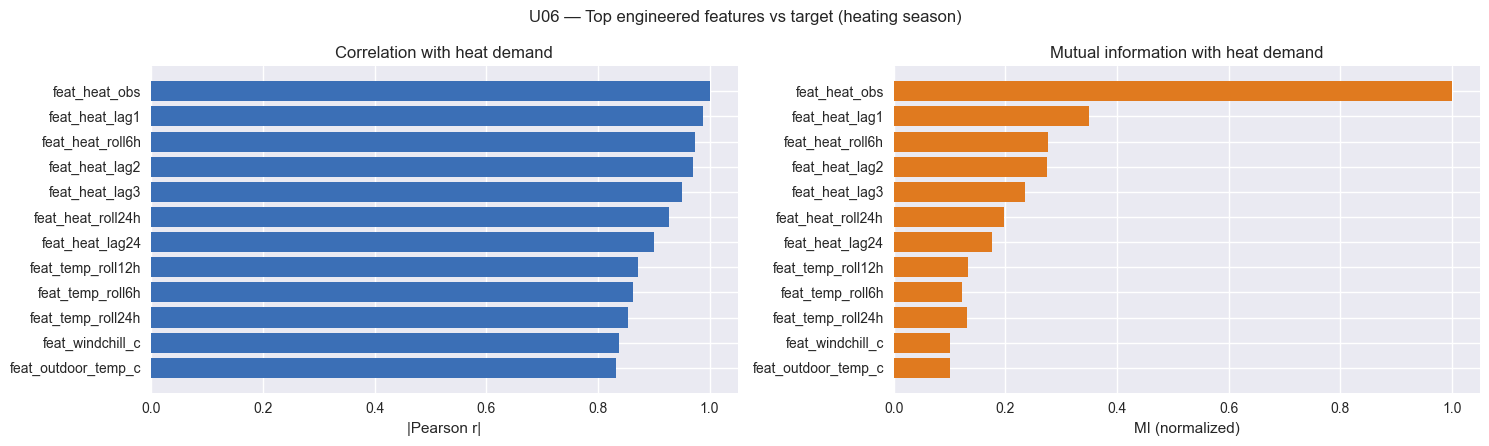

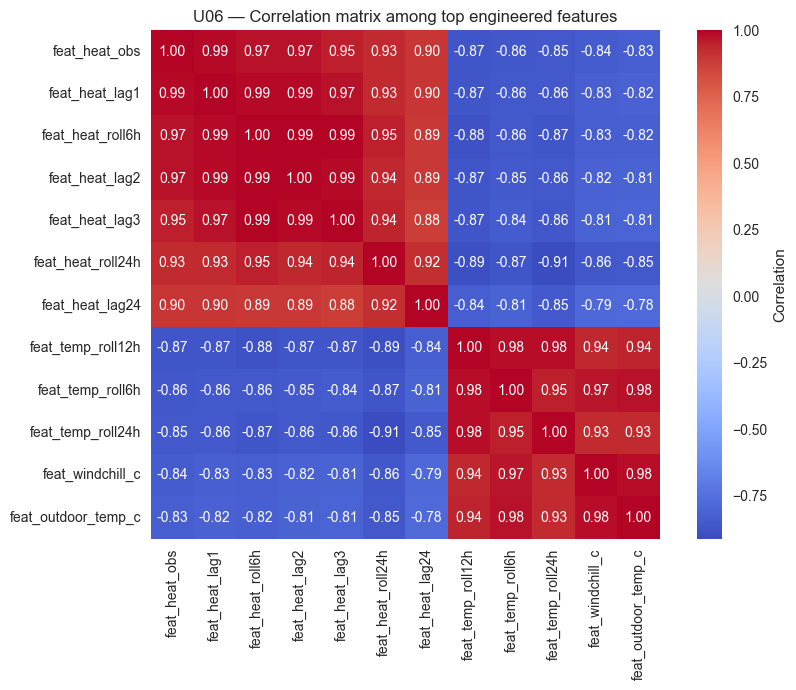

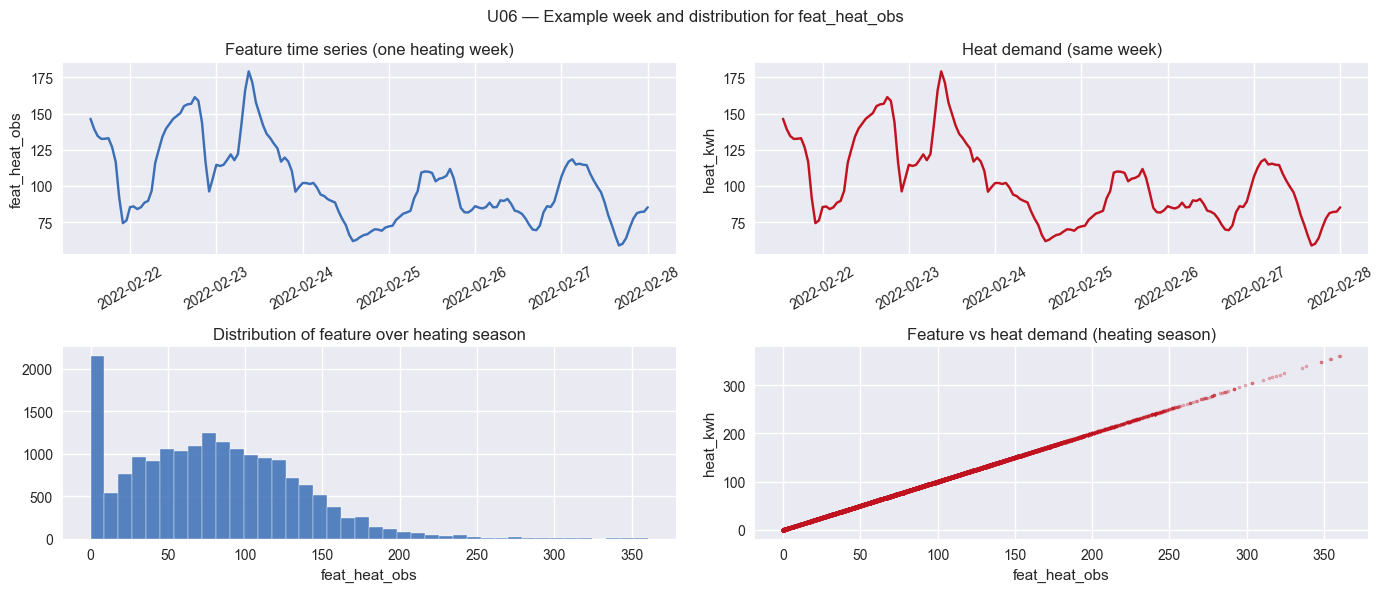


U05 — feature relevance (heating season, complete rows=18100):
                        pearson_r     abs_r        mi  is_constant         vif
feat_heat_obs            1.000000  1.000000  6.500381        False   47.936644
feat_heat_lag1           0.966881  0.966881  2.340511        False   75.074508
feat_heat_roll6h         0.923933  0.923933  1.952597        False  251.089632
feat_heat_lag2           0.919891  0.919891  1.933887        False   77.664303
feat_heat_lag24          0.879349  0.879349  1.517214        False   10.383953
feat_heat_lag3           0.859600  0.859600  1.705415        False  106.458986
feat_heat_roll24h        0.833881  0.833881  1.456633        False   14.686689
feat_heat_lag168         0.813423  0.813423  1.159057        False    5.770234
feat_temp_roll12h       -0.684213  0.684213  0.646714        False  115.468877
feat_temp_roll24h       -0.676896  0.676896  0.713712        False   40.169946
feat_temp_roll6h        -0.671617  0.671617  0.578804        False 

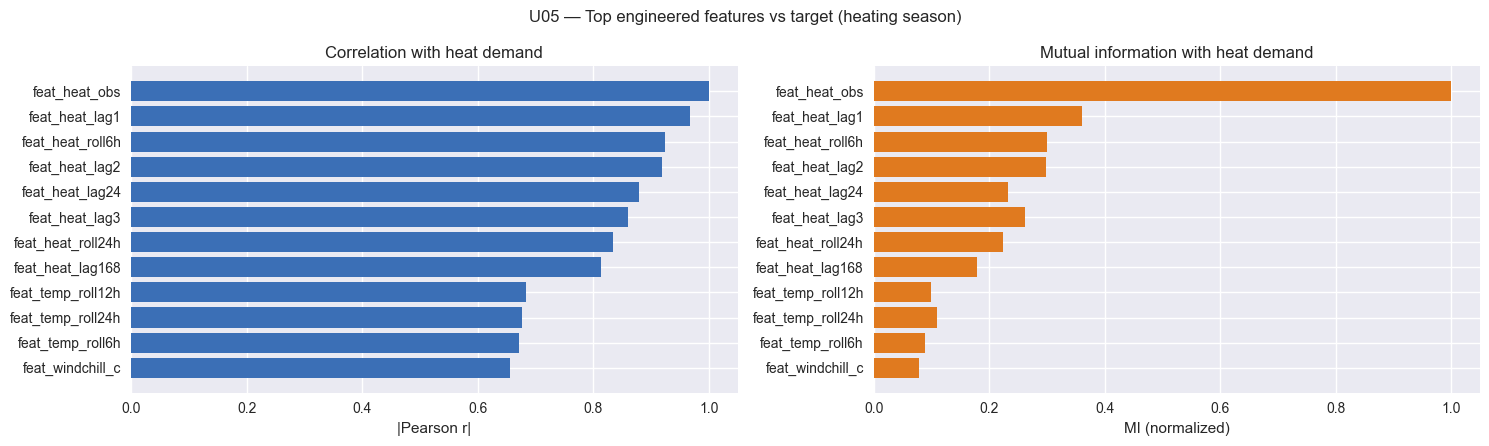

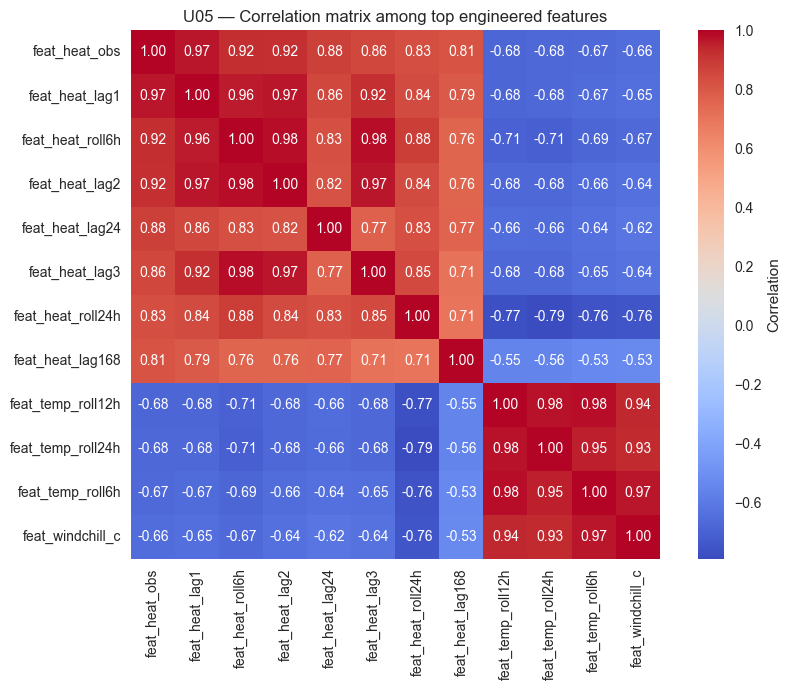

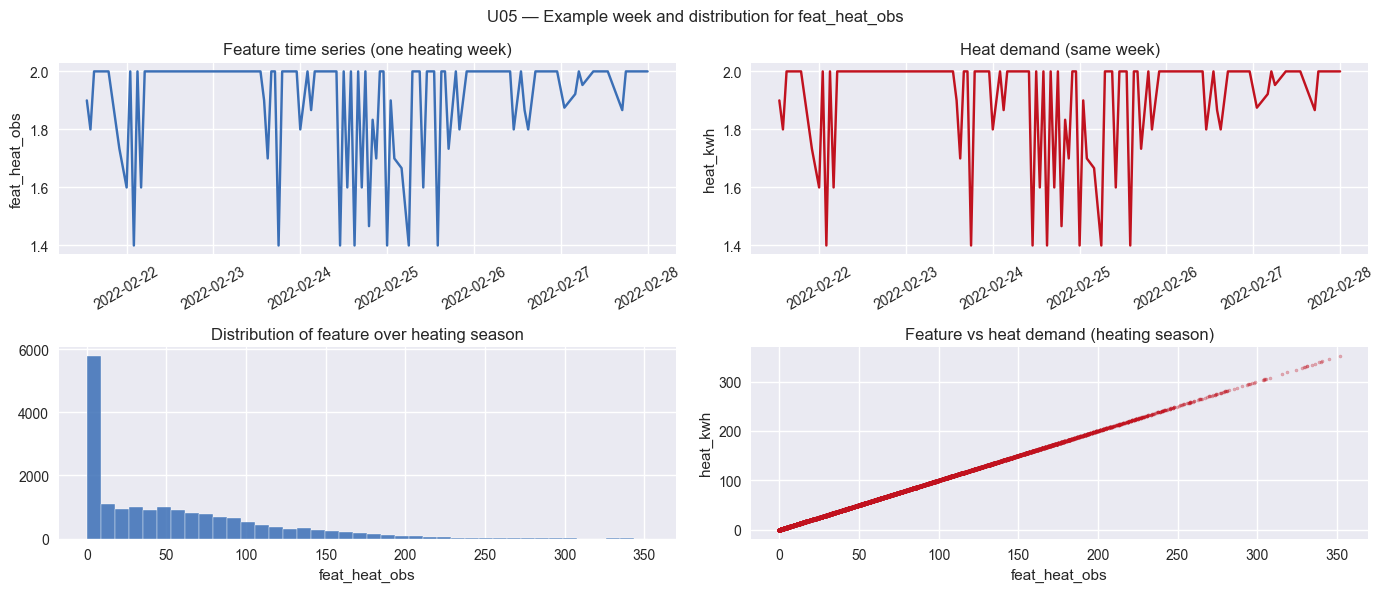

In [6]:
# Cell 4 — Feature relevance analysis (U06, U05) + plots

from sklearn.preprocessing import StandardScaler

PRIMARY_FOR_ANALYSIS = PRIMARY_BUILDINGS
analysis_results = {}

for bldg in PRIMARY_FOR_ANALYSIS:
    if bldg not in building_dfs:
        continue
    df = building_dfs[bldg].copy()

    mask = (df["heat_kwh"].notna()) & (_safe_numeric(df, "wx_outdoor_temp_c") < HEATING_THRESHOLD_C)
    df_h = df.loc[mask].copy()

    feature_cols = [
        c for c in df_h.columns
        if c.startswith("feat_") or c.startswith("stat_") or c.startswith("ehr_")
    ]
    X = df_h[feature_cols].dropna()
    y = df_h.loc[X.index, "heat_kwh"]

    if X.empty:
        print(f"{bldg}: no complete rows for analysis.")
        continue

    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    varying_cols = [c for c in X.columns if c not in constant_cols]

    corr = pd.Series(index=feature_cols, dtype=float)
    if varying_cols:
        corr.loc[varying_cols] = X[varying_cols].apply(lambda col: col.corr(y))

    mi_series = pd.Series(0.0, index=feature_cols, dtype=float)
    if varying_cols:
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X[varying_cols].values)
        mi_vals = mutual_info_regression(X_scaled, y.values, random_state=42)
        mi_series.loc[varying_cols] = mi_vals

    analysis_results[bldg] = {
        "features": feature_cols,
        "pearson": corr,
        "mi": mi_series,
    }

    summary = pd.DataFrame({
        "pearson_r": corr,
        "abs_r": corr.abs().fillna(0.0),
        "mi": mi_series,
        "is_constant": [feat in constant_cols for feat in feature_cols],
    }).sort_values(["abs_r", "mi"], ascending=[False, False])

    top_k = 12
    top_feats = [f for f in summary.index.tolist() if f not in constant_cols][:top_k]
    X_top = X[top_feats].copy() if top_feats else pd.DataFrame(index=X.index)

    vif_series = pd.Series(dtype=float)
    if len(top_feats) >= 2:
        vif_vals = []
        for i, col in enumerate(X_top.columns):
            try:
                vif_vals.append(variance_inflation_factor(X_top.values, i))
            except Exception:
                vif_vals.append(np.nan)
        vif_series = pd.Series(vif_vals, index=top_feats, name="vif")
        summary.loc[top_feats, "vif"] = vif_series

    print(f"\n{bldg} — feature relevance (heating season, complete rows={len(X)}):")
    print(summary.head(25).to_string())

    if not vif_series.empty:
        print("\nVIF for top varying features (higher than ~10 suggests strong multicollinearity):")
        print(vif_series.sort_values(ascending=False).to_string())

    top_summary = summary.loc[top_feats]
    feats = top_summary.index.tolist()
    if not feats:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
    fig.suptitle(f"{bldg} — Top engineered features vs target (heating season)")

    axes[0].barh(range(len(feats)), top_summary["abs_r"][::-1], color="#3b6fb6")
    axes[0].set_yticks(range(len(feats)))
    axes[0].set_yticklabels(feats[::-1])
    axes[0].set_xlabel("|Pearson r|")
    axes[0].set_title("Correlation with heat demand")

    mi_norm = top_summary["mi"] / (top_summary["mi"].max() or 1.0)
    axes[1].barh(range(len(feats)), mi_norm[::-1], color="#e07a1f")
    axes[1].set_yticks(range(len(feats)))
    axes[1].set_yticklabels(feats[::-1])
    axes[1].set_xlabel("MI (normalized)")
    axes[1].set_title("Mutual information with heat demand")

    plt.tight_layout()
    plt.show()

    corr_mat = X[feats].corr()
    plt.figure(figsize=(9, 7))
    sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", square=True,
                cbar_kws={"label": "Correlation"})
    plt.title(f"{bldg} — Correlation matrix among top engineered features")
    plt.tight_layout()
    plt.show()

    main_feat = feats[0]
    ts = df_h.loc[X.index, [main_feat, "heat_kwh"]].dropna()
    if not ts.empty:
        week_start = ts.index.min()
        week_end = week_start + pd.Timedelta(days=7)
        ts_week = ts.loc[week_start:week_end]

        fig, axes = plt.subplots(2, 2, figsize=(14, 6))
        fig.suptitle(f"{bldg} — Example week and distribution for {main_feat}")

        axes[0, 0].plot(ts_week.index, ts_week[main_feat], color="#3b6fb6")
        axes[0, 0].set_ylabel(main_feat)
        axes[0, 0].set_title("Feature time series (one heating week)")
        axes[0, 0].tick_params(axis="x", rotation=30)

        axes[0, 1].plot(ts_week.index, ts_week["heat_kwh"], color="#c1121f")
        axes[0, 1].set_ylabel("heat_kwh")
        axes[0, 1].set_title("Heat demand (same week)")
        axes[0, 1].tick_params(axis="x", rotation=30)

        hist_vals = pd.Series(ts[main_feat]).replace([np.inf, -np.inf], np.nan).dropna()
        axes[1, 0].hist(hist_vals, bins=40, color="#3b6fb6", alpha=0.85, edgecolor="white")
        axes[1, 0].set_xlabel(main_feat)
        axes[1, 0].set_title("Distribution of feature over heating season")

        axes[1, 1].scatter(ts[main_feat], ts["heat_kwh"], s=5, alpha=0.3, color="#c1121f")
        axes[1, 1].set_xlabel(main_feat)
        axes[1, 1].set_ylabel("heat_kwh")
        axes[1, 1].set_title("Feature vs heat demand (heating season)")

        plt.tight_layout()
        plt.show()


## Cell 4b — Feature selection notes

The final exported feature families now follow a stricter split:

- `setA` keeps **time-varying** signals only:
  - weather and exogenous context,
  - raw observed heat plus compact demand-memory / lag features,
  - subsystem `deltaT` and low-`deltaT` dynamics,
  - calendar / schedule features.
- `setB` adds **static or broadcast** signals:
  - building descriptors from `building_static_features.csv`,
  - structural EHR proxy features,
  - train-window summary metrics computed only from 2022-2023,
  - and explicit missingness flags wherever static numeric fields had to be imputed.

Selection principles:
- Keep features that are physically meaningful for short-term heat demand.
- Prefer signals that are consistent with the `00_` notebook findings: temperature, recent demand, subsystem `deltaT`, low-`deltaT` behavior, and building/system segmentation.
- Avoid leakage by computing target-derived static summaries from the training window only.
- Preserve a clear boundary between temporal features (`feat_*`) and static features (`stat_*`, `ehr_*`) so downstream notebooks can route them into the correct model branches.
- Preserve missing metadata as information: when a static numeric feature is unavailable, `setB` keeps a matching missingness flag instead of silently dropping the whole building.


Group-wise MI importance by building (share %):
group_label  Calendar / schedule  Demand memory  Other  Static descriptors  Structural EHR proxies  System deltaT / control  Train-window summaries  Weather / exogenous
building                                                                                                                                                                
U05                          6.7           47.8   25.7                 0.0                     0.0                      4.3                     0.0                 15.5
U06                          3.5           32.6   20.3                 0.0                     0.0                     28.3                     0.0                 15.2


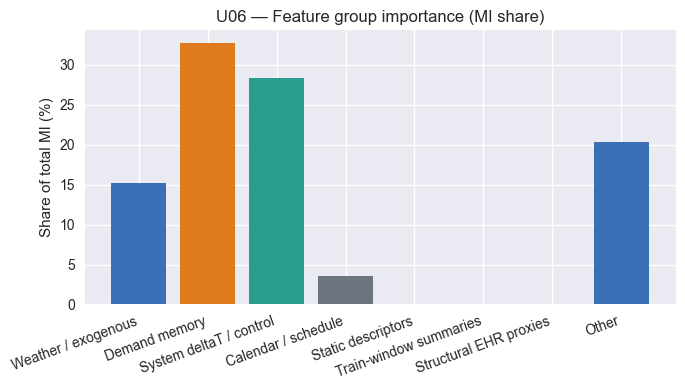

In [7]:
# Cell 4c — Group-wise feature importance (weather, demand memory, system, calendar, static)

GROUP_LABELS = {
    "weather": "Weather / exogenous",
    "demand": "Demand memory",
    "system": "System deltaT / control",
    "calendar": "Calendar / schedule",
    "static": "Static descriptors",
    "train_static": "Train-window summaries",
    "ehr": "Structural EHR proxies",
    "other": "Other",
}


def _feature_group(name: str) -> str:
    if name.startswith("stat_train_"):
        return "train_static"
    if name.startswith("stat_"):
        return "static"
    if name.startswith("ehr_"):
        return "ehr"
    if not name.startswith("feat_"):
        return "other"

    if any(k in name for k in [
        "outdoor_temp", "windchill", "hdh", "temp_", "solar", "rh_",
        "wind_ms", "sunshine", "heating_weather",
    ]):
        return "weather"
    if any(k in name for k in ["heat_lag", "heat_roll"]):
        return "demand"
    if any(k in name for k in ["space_", "vent_", "dhw_"]):
        return "system"
    if any(k in name for k in ["hour_", "dow_", "month_", "is_weekend", "is_night", "is_daytime"]):
        return "calendar"
    return "other"


group_importance_rows = []
for bldg, res in analysis_results.items():
    mi_abs = res["mi"].abs()
    total_mi = mi_abs.sum() or 1.0

    group_sums = {g: 0.0 for g in GROUP_LABELS}
    for feat, val in mi_abs.items():
        group_sums[_feature_group(feat)] += float(val)

    for g, val in group_sums.items():
        group_importance_rows.append({
            "building": bldg,
            "group": g,
            "group_label": GROUP_LABELS[g],
            "mi_sum": val,
            "mi_share_pct": 100.0 * val / total_mi,
        })

if group_importance_rows:
    group_imp_df = pd.DataFrame(group_importance_rows)
    print("Group-wise MI importance by building (share %):")
    print(group_imp_df.pivot(index="building", columns="group_label", values="mi_share_pct").round(1).to_string())

    if "U06" in group_imp_df["building"].unique():
        u06 = group_imp_df[group_imp_df["building"] == "U06"]
        plt.figure(figsize=(7, 4))
        plt.bar(
            u06["group_label"],
            u06["mi_share_pct"],
            color=["#3b6fb6", "#e07a1f", "#2a9d8f", "#6c757d", "#c1121f", "#7a6c5d", "#9c6644"],
        )
        plt.ylabel("Share of total MI (%)")
        plt.xticks(rotation=20, ha="right")
        plt.title("U06 — Feature group importance (MI share)")
        plt.tight_layout()
        plt.show()


In [8]:
# Cell 5 — Define feature sets (temporal only / temporal + static)

WEATHER_FEATURES_SELECTED = [
    "feat_outdoor_temp_c",
    "feat_windchill_c",
    "feat_hdh_15c",
    "feat_is_heating_weather",
    "feat_temp_roll6h",
    "feat_temp_roll12h",
    "feat_temp_roll24h",
    "feat_temp_diff1h",
    "feat_temp_diff3h",
    "feat_solar_irradiance_wm2",
    "feat_sunshine_min",
    "feat_rh_pct",
    "feat_wind_ms",
]

DEMAND_MEMORY_FEATURES_SELECTED = [
    "feat_heat_obs",
    "feat_heat_lag1",
    "feat_heat_lag2",
    "feat_heat_lag3",
    "feat_heat_lag24",
    "feat_heat_lag168",
    "feat_heat_roll6h",
    "feat_heat_roll24h",
]

SYSTEM_DYNAMIC_FEATURES_SELECTED = [
    "feat_space_heat_active",
    "feat_space_deltaT_c",
    "feat_space_deltaT_lag1",
    "feat_space_deltaT_roll6h",
    "feat_space_deltaT_roll24h",
    "feat_space_low_deltaT_flag",
    "feat_space_low_deltaT_roll24h",
    "feat_vent_heat_active",
    "feat_vent_deltaT_c",
    "feat_vent_deltaT_lag1",
    "feat_vent_deltaT_roll6h",
    "feat_vent_deltaT_roll24h",
    "feat_vent_low_deltaT_flag",
    "feat_vent_low_deltaT_roll24h",
    "feat_dhw_heat_active",
    "feat_dhw_deltaT_c",
    "feat_dhw_deltaT_lag1",
    "feat_dhw_deltaT_roll6h",
    "feat_dhw_deltaT_roll24h",
    "feat_dhw_low_deltaT_flag",
    "feat_dhw_low_deltaT_roll24h",
]

CALENDAR_FEATURES_SELECTED = [
    "feat_hour_sin",
    "feat_hour_cos",
    "feat_dow_sin",
    "feat_dow_cos",
    "feat_month_sin",
    "feat_month_cos",
    "feat_is_weekend",
    "feat_is_night",
    "feat_is_daytime",
]

STATIC_DESCRIPTOR_FEATURES_SELECTED = STATIC_DESCRIPTOR_FEATURES
TRAIN_SUMMARY_FEATURES_SELECTED = TRAIN_SUMMARY_FEATURES
EHR_FEATURES_SELECTED = EHR_STRUCTURAL_FEATURES
STATIC_MISSINGNESS_FEATURES_SELECTED = STATIC_MISSINGNESS_FEATURES

BASE_FEATURES_NO_EHR = (
    WEATHER_FEATURES_SELECTED
    + DEMAND_MEMORY_FEATURES_SELECTED
    + SYSTEM_DYNAMIC_FEATURES_SELECTED
    + CALENDAR_FEATURES_SELECTED
)
BASE_FEATURES_WITH_EHR = (
    BASE_FEATURES_NO_EHR
    + STATIC_DESCRIPTOR_FEATURES_SELECTED
    + TRAIN_SUMMARY_FEATURES_SELECTED
    + EHR_FEATURES_SELECTED
    + STATIC_MISSINGNESS_FEATURES_SELECTED
)

print("Feature set A (temporal only):")
print(BASE_FEATURES_NO_EHR)
print()
print("Feature set B (temporal + static + missingness flags):")
print(BASE_FEATURES_WITH_EHR)


Feature set A (temporal only):
['feat_outdoor_temp_c', 'feat_windchill_c', 'feat_hdh_15c', 'feat_is_heating_weather', 'feat_temp_roll6h', 'feat_temp_roll12h', 'feat_temp_roll24h', 'feat_temp_diff1h', 'feat_temp_diff3h', 'feat_solar_irradiance_wm2', 'feat_sunshine_min', 'feat_rh_pct', 'feat_wind_ms', 'feat_heat_obs', 'feat_heat_lag1', 'feat_heat_lag2', 'feat_heat_lag3', 'feat_heat_lag24', 'feat_heat_lag168', 'feat_heat_roll6h', 'feat_heat_roll24h', 'feat_space_heat_active', 'feat_space_deltaT_c', 'feat_space_deltaT_lag1', 'feat_space_deltaT_roll6h', 'feat_space_deltaT_roll24h', 'feat_space_low_deltaT_flag', 'feat_space_low_deltaT_roll24h', 'feat_vent_heat_active', 'feat_vent_deltaT_c', 'feat_vent_deltaT_lag1', 'feat_vent_deltaT_roll6h', 'feat_vent_deltaT_roll24h', 'feat_vent_low_deltaT_flag', 'feat_vent_low_deltaT_roll24h', 'feat_dhw_heat_active', 'feat_dhw_deltaT_c', 'feat_dhw_deltaT_lag1', 'feat_dhw_deltaT_roll6h', 'feat_dhw_deltaT_roll24h', 'feat_dhw_low_deltaT_flag', 'feat_dhw_low_d

In [9]:
# Cell 6 — Build explicit training datasets for all buildings

portfolio_rows = []
STATIC_SETB_FEATURES = STATIC_DESCRIPTOR_FEATURES_SELECTED + TRAIN_SUMMARY_FEATURES_SELECTED + EHR_FEATURES_SELECTED

for bldg, df in building_dfs.items():
    cov = coverage_df.loc[coverage_df["building"] == bldg].iloc[0]
    first_obs = cov["first_obs"]
    last_obs = cov["last_obs"]

    train_mask = df.index <= TRAIN_END
    test_mask = df.index > TRAIN_END

    X_no_ehr = df[BASE_FEATURES_NO_EHR].copy()
    X_ehr = df[BASE_FEATURES_WITH_EHR].copy()
    y = df["heat_kwh"].copy()

    train_complete_mask_A = train_mask & y.notna() & X_no_ehr.notna().all(axis=1)
    test_complete_mask_A = test_mask & y.notna() & X_no_ehr.notna().all(axis=1)
    train_complete_mask_B = train_mask & y.notna() & X_ehr.notna().all(axis=1)
    test_complete_mask_B = test_mask & y.notna() & X_ehr.notna().all(axis=1)

    portfolio_rows.append({
        "building": bldg,
        "first_obs": first_obs,
        "last_obs": last_obs,
        "target_kind": cov.get("target_kind", pd.NA),
        "train_rows": int(train_mask.sum()),
        "train_complete_rows_setA": int(train_complete_mask_A.sum()),
        "train_complete_rows_setB": int(train_complete_mask_B.sum()),
        "test_rows": int(test_mask.sum()),
        "test_complete_rows_setA": int(test_complete_mask_A.sum()),
        "test_complete_rows_setB": int(test_complete_mask_B.sum()),
        "static_complete_any": bool(df[STATIC_SETB_FEATURES].notna().all(axis=1).any()) if STATIC_SETB_FEATURES else False,
    })

portfolio_df = pd.DataFrame(portfolio_rows).sort_values("building").reset_index(drop=True)

print("Portfolio training dataset coverage (per building):")
print(portfolio_df.to_string(index=False))


Portfolio training dataset coverage (per building):
building           first_obs            last_obs    target_kind  train_rows  train_complete_rows_setA  train_complete_rows_setB  test_rows  test_complete_rows_setA  test_complete_rows_setB  static_complete_any
     GEO 2022-05-23 12:00:00 2024-12-31 23:00:00 weather_driven       17497                     13416                     13416       8807                     8489                     8489                 True
     ICO 2022-05-20 13:00:00 2024-12-31 23:00:00 weather_driven       17497                     13487                     13487       8807                     8489                     8489                 True
     LIB 2022-05-20 14:00:00 2024-12-31 23:00:00 weather_driven       17497                     13486                     13486       8807                     8489                     8489                 True
     SOC 2022-05-20 14:00:00 2024-12-31 23:00:00 weather_driven       17497                     13486       

In [10]:
# Cell 7 — Export feature datasets and metadata

feature_metadata = []
feature_catalog_rows = []
TARGET_EXPORT_COLS = ["heat_kwh", "heat_kwh_m2"]

for feat in BASE_FEATURES_WITH_EHR:
    feature_catalog_rows.append({
        "feature_name": feat,
        "feature_group": _feature_group(feat),
        "in_setA": feat in BASE_FEATURES_NO_EHR,
        "in_setB": feat in BASE_FEATURES_WITH_EHR,
        "is_static": feat.startswith("stat_") or feat.startswith("ehr_"),
        "source": (
            "01_static_companion" if feat.startswith("stat_") and not feat.startswith("stat_train_") else
            "03_train_window_summary" if feat.startswith("stat_train_") else
            "ehr_summary_structural" if feat.startswith("ehr_") else
            "01_hourly_clean_and_weather"
        ),
    })

for bldg, df in building_dfs.items():
    mask_target = df["heat_kwh"].notna()
    target_cols = [col for col in TARGET_EXPORT_COLS if col in df.columns]
    df_no_ehr = df.loc[mask_target, BASE_FEATURES_NO_EHR + target_cols].copy()
    df_with_ehr = df.loc[mask_target, BASE_FEATURES_WITH_EHR + target_cols].copy()

    path_no_ehr = FEATURE_DIR / f"{bldg}_features_setA.csv"
    path_with_ehr = FEATURE_DIR / f"{bldg}_features_setB.csv"

    df_no_ehr.to_csv(path_no_ehr, index_label="datetime")
    df_with_ehr.to_csv(path_with_ehr, index_label="datetime")

    feature_metadata.append({
        "building": bldg,
        "path_setA": str(path_no_ehr.relative_to(PROJECT_ROOT)),
        "path_setB": str(path_with_ehr.relative_to(PROJECT_ROOT)),
        "n_rows_setA": len(df_no_ehr),
        "n_rows_setB": len(df_with_ehr),
        "n_features_setA": len(BASE_FEATURES_NO_EHR),
        "n_features_setB": len(BASE_FEATURES_WITH_EHR),
        "target_columns": ",".join(target_cols),
    })

meta_df = pd.DataFrame(feature_metadata)
meta_path = FEATURE_DIR / "feature_metadata.csv"
meta_df.to_csv(meta_path, index=False)

portfolio_path = FEATURE_DIR / "portfolio_coverage.csv"
portfolio_df.to_csv(portfolio_path, index=False)

feature_catalog_df = pd.DataFrame(feature_catalog_rows).drop_duplicates(subset=["feature_name"]).sort_values("feature_name")
feature_catalog_path = FEATURE_DIR / "feature_catalog.csv"
feature_catalog_df.to_csv(feature_catalog_path, index=False)

print("Saved feature datasets and metadata:")
print(meta_df.to_string(index=False))
print()
print(f"Target columns exported: {TARGET_EXPORT_COLS}")
print()
print(f"Portfolio coverage saved to: {portfolio_path}")
print(f"Feature catalog saved to: {feature_catalog_path}")




Saved feature datasets and metadata:
building                              path_setA                              path_setB  n_rows_setA  n_rows_setB  n_features_setA  n_features_setB       target_columns
     GEO    data/features/GEO_features_setA.csv    data/features/GEO_features_setB.csv        22884        22884               51              141 heat_kwh,heat_kwh_m2
     ICO    data/features/ICO_features_setA.csv    data/features/ICO_features_setB.csv        22955        22955               51              141 heat_kwh,heat_kwh_m2
     LIB    data/features/LIB_features_setA.csv    data/features/LIB_features_setB.csv        22954        22954               51              141 heat_kwh,heat_kwh_m2
     SOC    data/features/SOC_features_setA.csv    data/features/SOC_features_setB.csv        22954        22954               51              141 heat_kwh,heat_kwh_m2
     STU    data/features/STU_features_setA.csv    data/features/STU_features_setB.csv        17607        17607           